# High-Imbalance Event Flow

This notebook treats strong order-book imbalance as an event-flow signal rather than only a snapshot state.

The key question is:

$$
E[\Delta P_h(t) \mid N^{imb}_{W}(t)]
$$

where:

- $\Delta P_h(t) = M_{t+h} - M_t$ is the future midprice change over horizon $h$ milliseconds
- $N^{imb}_{W}(t)$ is the number of recent entries into strong imbalance regimes over the lookback window $W$
- strong buy-heavy and strong sell-heavy events are counted separately and also as a net count

Plain-language goal: test whether repeated entries into strong imbalance regimes are more informative than the current imbalance snapshot alone.


## 1. Parameters

The parameters intentionally mirror the other order-book imbalance notebooks where possible.


In [1]:
# Notebook parameters.

SYMBOL = "BTCUSDC"
DAYS = ["20260225"]

BOOK_REPLAY_LEVELS = 5
IMBALANCE_LEVELS = 2
N_REGIMES = 5

# Lookback windows for counting high-imbalance entry events, in milliseconds.
EVENT_WINDOWS_MS = [250, 500, 1000, 2000, 3000]

# Event-window lengths for the last-N high-imbalance event composition features.
LAST_EVENT_COUNTS_N = [3, 5, 10]

# Forward midprice horizons, in milliseconds.
FUTURE_PRICE_HORIZONS_MS = [100, 250, 500, 1000, 2000, 3000]

SHOW_REPLAY_PROGRESS = True
REPLAY_ON_GAP = "skip-segment"

# Optional display controls.
DISPLAY_ROWS = 50


## 2. Setup and Data Loading

This notebook only needs replayed order-book levels. It does not use trade-flow imbalance or market-order direction.


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_backtester_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1] if len(Path.cwd().parents) > 1 else Path.cwd()]
    for candidate in candidates:
        if (candidate / "stats").is_dir() and (candidate / "notebooks").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the exchange-data-backtester project root")


def resolve_day_dir(project_root: Path, *, symbol: str, day: str) -> Path:
    candidates = [
        project_root.parent / "exchange-data-recorder" / "data" / "binance" / symbol / day,
        project_root.parent / "exchange-data-recorder" / "data" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / "binance" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / symbol / day,
        project_root / "data" / "binance" / symbol / day,
        project_root / "data" / symbol / day,
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "schema.json").is_file():
            return candidate
    raise FileNotFoundError(f"Could not locate a recorder day folder for {symbol}/{day}")


PROJECT_ROOT = find_backtester_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from stats.features.book import compute_depth_imbalance, compute_mid_spread
from stats.io import load_day
from stats.notebook import replay_summary
from stats.tables import get_or_build_book_levels_table

loaded_days = []
book_parts = []

for day in DAYS:
    day_dir = resolve_day_dir(PROJECT_ROOT, symbol=SYMBOL, day=day)
    dataset = load_day(day_dir)
    replay_info = replay_summary(dataset, replay_on_gap=REPLAY_ON_GAP)

    if IMBALANCE_LEVELS > BOOK_REPLAY_LEVELS:
        raise ValueError("IMBALANCE_LEVELS cannot exceed BOOK_REPLAY_LEVELS")

    print(f"Loading {SYMBOL} {day}: book levels top_n={BOOK_REPLAY_LEVELS}, replay_on_gap={REPLAY_ON_GAP}", flush=True)
    book_day = get_or_build_book_levels_table(
        dataset,
        top_n=BOOK_REPLAY_LEVELS,
        on_gap=REPLAY_ON_GAP,
        show_progress=SHOW_REPLAY_PROGRESS,
    )
    print(f"Loaded {SYMBOL} {day}: {len(book_day):,} book rows", flush=True)

    book_day = book_day.copy()
    book_day["source_day"] = day
    book_parts.append(book_day)
    loaded_days.append({"day": day, "day_dir": str(day_dir), "book_rows": len(book_day), **replay_info})

book_levels = pd.concat(book_parts, ignore_index=True).sort_values(["source_day", "recv_time_ms", "recv_seq"])

load_summary = pd.DataFrame(loaded_days)
display(load_summary)


Loading BTCUSDC 20260225: book levels top_n=5, replay_on_gap=skip-segment
Loaded BTCUSDC 20260225: 724,751 book rows


,day,day_dir,book_rows,replay_on_gap,segments_total,segments_kept,segments_skipped
0,20260225,/Users/hoangdeveloper/PycharmProjects/exchange...,724751,skip-segment,2,1,1


## 3. Imbalance State Construction

We first build the same snapshot imbalance variables used in the earlier notebooks:

$$
\rho_t = \frac{V^b_t - V^a_t}{V^b_t + V^a_t}
$$

where $V^b_t$ and $V^a_t$ are the summed bid and ask quantities over the first `IMBALANCE_LEVELS` book levels.

Then we split $\rho_t$ into `N_REGIMES` regimes. With the default `N_REGIMES = 5`, the strongest tails are `strong sell-heavy` and `strong buy-heavy`.


In [3]:
def regime_labels(n_regimes: int) -> dict[int, str]:
    if n_regimes == 5:
        return {
            1: "strong sell-heavy",
            2: "mild sell-heavy",
            3: "neutral",
            4: "mild buy-heavy",
            5: "strong buy-heavy",
        }
    return {idx: f"Z={idx}" for idx in range(1, n_regimes + 1)}


def add_imbalance_features(book: pd.DataFrame, *, depth_levels: int, n_regimes: int) -> pd.DataFrame:
    out = book.copy()
    mid_spread = compute_mid_spread(out)
    depth_imbalance = compute_depth_imbalance(out, levels=[depth_levels])

    out["mid"] = mid_spread["mid"]
    out["spread"] = mid_spread["spread"]
    out["spread_bps"] = mid_spread["spread_bps"]
    out["rho"] = depth_imbalance[f"imbalance_{depth_levels}"].clip(-1, 1)

    edges = np.linspace(-1.0, 1.0, n_regimes + 1)
    labels = list(range(1, n_regimes + 1))
    out["Z"] = pd.cut(out["rho"], bins=edges, labels=labels, include_lowest=True).astype("Int64")
    out["Z_label"] = out["Z"].map(regime_labels(n_regimes)).astype("string")

    out = out.sort_values(["source_day", "epoch_id", "segment_index", "recv_time_ms", "recv_seq"]).reset_index(drop=True)
    group_cols = ["source_day", "epoch_id", "segment_index"]
    next_time = out.groupby(group_cols, dropna=False)["recv_time_ms"].shift(-1)
    out["dt_ms"] = (next_time - out["recv_time_ms"]).clip(lower=0).fillna(0)
    out["ts"] = pd.to_datetime(out["recv_time_ms"], unit="ms", utc=True)
    return out


features = add_imbalance_features(book_levels, depth_levels=IMBALANCE_LEVELS, n_regimes=N_REGIMES)

summary_cols = ["source_day", "recv_time_ms", "ts", "mid", "rho", "Z", "Z_label", "dt_ms"]
display(features[summary_cols].head(DISPLAY_ROWS))
display(features[["rho", "dt_ms", "spread"]].describe())


,source_day,recv_time_ms,ts,mid,rho,Z,Z_label,dt_ms
0,20260225,1771981204734,2026-02-25 01:00:04.734000+00:00,64243.015,-0.432433,2,mild sell-heavy,100.0
1,20260225,1771981204834,2026-02-25 01:00:04.834000+00:00,64243.015,-0.432433,2,mild sell-heavy,101.0
2,20260225,1771981204935,2026-02-25 01:00:04.935000+00:00,64243.015,-0.487944,2,mild sell-heavy,100.0
3,20260225,1771981205035,2026-02-25 01:00:05.035000+00:00,64243.015,0.772590,5,strong buy-heavy,100.0
4,20260225,1771981205135,2026-02-25 01:00:05.135000+00:00,64243.015,0.525605,4,mild buy-heavy,99.0
5,20260225,1771981205234,2026-02-25 01:00:05.234000+00:00,64243.015,0.995610,5,strong buy-heavy,100.0
6,20260225,1771981205334,2026-02-25 01:00:05.334000+00:00,64247.195,0.720654,5,strong buy-heavy,100.0
7,20260225,1771981205434,2026-02-25 01:00:05.434000+00:00,64247.195,0.998295,5,strong buy-heavy,100.0
8,20260225,1771981205534,2026-02-25 01:00:05.534000+00:00,64250.995,0.738255,5,strong buy-heavy,100.0
9,20260225,1771981205634,2026-02-25 01:00:05.634000+00:00,64250.995,0.488470,4,mild buy-heavy,101.0


,rho,dt_ms,spread
count,724751.000000,724751.000000,724751.000000
mean,0.006707,110.514232,0.029293
std,0.614824,44.524263,0.382795
min,-0.999920,0.000000,0.010000
25%,-0.524960,100.000000,0.010000
50%,0.016246,100.000000,0.010000
75%,0.537977,100.000000,0.010000
max,0.999940,1504.000000,52.080000


## 4. High-Imbalance Entry Events

A high-imbalance event is an **entry** into a strong imbalance regime, not every row while the regime persists.

For the default five-regime setup:

$$
E^{buy}_t = 1\{Z_t = \text{strong buy-heavy}\ \text{and}\ Z_{t-1} \ne \text{strong buy-heavy}\}
$$

$$
E^{sell}_t = 1\{Z_t = \text{strong sell-heavy}\ \text{and}\ Z_{t-1} \ne \text{strong sell-heavy}\}
$$

This avoids double-counting a long persistent imbalance episode as many separate events just because the book updates frequently. The first row in each replay segment is not counted as an entry because the previous state is left-censored.


In [4]:
def mark_high_imbalance_events(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.sort_values(["source_day", "epoch_id", "segment_index", "recv_time_ms", "recv_seq"]).copy()
    group_cols = ["source_day", "epoch_id", "segment_index"]

    out["is_strong_buy_heavy"] = out["Z_label"].eq("strong buy-heavy")
    out["is_strong_sell_heavy"] = out["Z_label"].eq("strong sell-heavy")

    prev_buy = out.groupby(group_cols, dropna=False)["is_strong_buy_heavy"].shift(1)
    prev_sell = out.groupby(group_cols, dropna=False)["is_strong_sell_heavy"].shift(1)

    out["buy_high_imbalance_event"] = out["is_strong_buy_heavy"] & prev_buy.eq(False)
    out["sell_high_imbalance_event"] = out["is_strong_sell_heavy"] & prev_sell.eq(False)
    out["any_high_imbalance_event"] = out["buy_high_imbalance_event"] | out["sell_high_imbalance_event"]
    out["signed_high_imbalance_event"] = np.select(
        [out["buy_high_imbalance_event"], out["sell_high_imbalance_event"]],
        [1, -1],
        default=0,
    )
    return out


features = mark_high_imbalance_events(features)

event_summary = (
    features.groupby("source_day", dropna=False)
    .agg(
        rows=("recv_time_ms", "size"),
        buy_high_events=("buy_high_imbalance_event", "sum"),
        sell_high_events=("sell_high_imbalance_event", "sum"),
        any_high_events=("any_high_imbalance_event", "sum"),
        strong_buy_rows=("is_strong_buy_heavy", "sum"),
        strong_sell_rows=("is_strong_sell_heavy", "sum"),
    )
    .reset_index()
)
for col in ["buy_high_events", "sell_high_events", "any_high_events", "strong_buy_rows", "strong_sell_rows"]:
    event_summary[f"{col}_share"] = event_summary[col] / event_summary["rows"]

display(event_summary)
display(features.loc[features["any_high_imbalance_event"], ["source_day", "ts", "rho", "Z_label", "signed_high_imbalance_event"]].head(DISPLAY_ROWS))


,source_day,rows,buy_high_events,sell_high_events,any_high_events,strong_buy_rows,strong_sell_rows,buy_high_events_share,sell_high_events_share,any_high_events_share,strong_buy_rows_share,strong_sell_rows_share
0,20260225,724751,26905,27581,54486,160757,158145,0.037123,0.038056,0.075179,0.22181,0.218206


,source_day,ts,rho,Z_label,signed_high_imbalance_event
3,20260225,2026-02-25 01:00:05.035000+00:00,0.772590,strong buy-heavy,1
5,20260225,2026-02-25 01:00:05.234000+00:00,0.995610,strong buy-heavy,1
10,20260225,2026-02-25 01:00:05.735000+00:00,0.999263,strong buy-heavy,1
14,20260225,2026-02-25 01:00:06.135000+00:00,0.723755,strong buy-heavy,1
19,20260225,2026-02-25 01:00:06.635000+00:00,0.998968,strong buy-heavy,1
24,20260225,2026-02-25 01:00:07.135000+00:00,0.602302,strong buy-heavy,1
27,20260225,2026-02-25 01:00:07.434000+00:00,-0.720277,strong sell-heavy,-1
36,20260225,2026-02-25 01:00:08.334000+00:00,-0.916128,strong sell-heavy,-1
55,20260225,2026-02-25 01:00:10.234000+00:00,-0.605430,strong sell-heavy,-1
88,20260225,2026-02-25 01:00:13.534000+00:00,0.805371,strong buy-heavy,1


## 5. Recent Event Count Features

For each lookback window $W$, count entries into high-imbalance regimes over `(t-W, t]`:

$$
N^{buy}_{W}(t) = \sum_{s \in (t-W, t]} E^{buy}_s
$$

$$
N^{sell}_{W}(t) = \sum_{s \in (t-W, t]} E^{sell}_s
$$

We also compute:

$$
N^{net}_{W}(t) = N^{buy}_{W}(t) - N^{sell}_{W}(t)
$$

$$
N^{total}_{W}(t) = N^{buy}_{W}(t) + N^{sell}_{W}(t)
$$

Interpretation:

- `buy_event_count_W`: repeated entries into strong buy-heavy states
- `sell_event_count_W`: repeated entries into strong sell-heavy states
- `net_event_count_W`: directional event pressure
- `total_event_count_W`: recent high-imbalance activity regardless of direction


In [5]:
def _count_recent_events(event_times: np.ndarray, row_times: np.ndarray, window_ms: int) -> np.ndarray:
    right = np.searchsorted(event_times, row_times, side="right")
    left = np.searchsorted(event_times, row_times - window_ms, side="right")
    return right - left


def add_recent_high_imbalance_event_counts(frame: pd.DataFrame, *, windows_ms: list[int]) -> pd.DataFrame:
    out = frame.copy()
    group_cols = ["source_day", "epoch_id", "segment_index"]

    for window_ms in windows_ms:
        out[f"buy_event_count_{window_ms}ms"] = 0
        out[f"sell_event_count_{window_ms}ms"] = 0
        out[f"net_event_count_{window_ms}ms"] = 0
        out[f"total_event_count_{window_ms}ms"] = 0

    for _, idx in out.groupby(group_cols, dropna=False, sort=False).groups.items():
        part = out.loc[idx]
        row_times = part["recv_time_ms"].to_numpy(dtype="int64")
        buy_times = part.loc[part["buy_high_imbalance_event"], "recv_time_ms"].to_numpy(dtype="int64")
        sell_times = part.loc[part["sell_high_imbalance_event"], "recv_time_ms"].to_numpy(dtype="int64")

        for window_ms in windows_ms:
            buy_count = _count_recent_events(buy_times, row_times, window_ms)
            sell_count = _count_recent_events(sell_times, row_times, window_ms)
            out.loc[idx, f"buy_event_count_{window_ms}ms"] = buy_count
            out.loc[idx, f"sell_event_count_{window_ms}ms"] = sell_count
            out.loc[idx, f"net_event_count_{window_ms}ms"] = buy_count - sell_count
            out.loc[idx, f"total_event_count_{window_ms}ms"] = buy_count + sell_count

    return out


def summarize_event_count_features(frame: pd.DataFrame, *, windows_ms: list[int]) -> pd.DataFrame:
    rows = []
    for window_ms in windows_ms:
        for signal in ["buy", "sell", "net", "total"]:
            col = f"{signal}_event_count_{window_ms}ms"
            values = frame[col].dropna()
            rows.append(
                {
                    "window_ms": window_ms,
                    "signal": signal,
                    "mean": values.mean(),
                    "median": values.median(),
                    "p95": values.quantile(0.95),
                    "max": values.max(),
                    "share_nonzero": (values != 0).mean(),
                }
            )
    return pd.DataFrame(rows)


features = add_recent_high_imbalance_event_counts(features, windows_ms=EVENT_WINDOWS_MS)
event_count_summary = summarize_event_count_features(features, windows_ms=EVENT_WINDOWS_MS)
display(event_count_summary)


,window_ms,signal,mean,median,p95,max,share_nonzero
0,250,buy,0.109711,0.0,1.0,2,0.107398
1,250,sell,0.112759,0.0,1.0,2,0.110301
2,250,net,-0.003048,0.0,1.0,2,0.207010
3,250,total,0.222470,0.0,1.0,4,0.212281
4,500,buy,0.189399,0.0,1.0,3,0.173914
5,500,sell,0.195126,0.0,1.0,3,0.178459
6,500,net,-0.005727,0.0,1.0,3,0.311873
7,500,total,0.384525,0.0,1.0,5,0.330618
8,1000,buy,0.367192,0.0,2.0,5,0.292114
9,1000,sell,0.377974,0.0,2.0,5,0.298547


## 6. Last-N Event Composition Features

The previous section uses fixed clock-time windows such as `1000ms`. This section uses a fixed **number of high-imbalance events** instead.

For each row and each `N` in `LAST_EVENT_COUNTS_N`, we look at the last `N` high-imbalance entry events up to and including time `t`. Each event has a signed direction:

- `+1` for an entry into `strong buy-heavy`
- `-1` for an entry into `strong sell-heavy`

From those last events we compute:

- `last_N_buy_count`: number of buy-heavy entries in the last `N` available events
- `last_N_sell_count`: number of sell-heavy entries in the last `N` available events
- `last_N_event_count`: number of events available, capped at `N`
- `last_N_buy_share = buy_count / event_count`
- `last_N_signed_event_mean = mean(signed_event)`

`last_N_signed_event_mean` is bounded between `-1` and `+1`. A value near `+1` means the recent event composition is mostly buy-heavy. A value near `-1` means it is mostly sell-heavy. A value near `0` means the last events are balanced.

Rows before the first high-imbalance event have `NaN` for the share and signed mean because there is no event history yet.


In [6]:
def add_last_n_event_composition(frame: pd.DataFrame, *, counts_n: list[int]) -> pd.DataFrame:
    out = frame.copy()
    group_cols = ["source_day", "epoch_id", "segment_index"]

    for n_events in counts_n:
        out[f"last_{n_events}_buy_count"] = 0.0
        out[f"last_{n_events}_sell_count"] = 0.0
        out[f"last_{n_events}_event_count"] = 0.0
        out[f"last_{n_events}_buy_share"] = np.nan
        out[f"last_{n_events}_signed_event_mean"] = np.nan

    for _, idx in out.groupby(group_cols, dropna=False, sort=False).groups.items():
        part = out.loc[idx]
        row_times = part["recv_time_ms"].to_numpy(dtype="int64")
        event_part = part.loc[part["any_high_imbalance_event"], ["recv_time_ms", "signed_high_imbalance_event"]]
        event_times = event_part["recv_time_ms"].to_numpy(dtype="int64")
        event_signs = event_part["signed_high_imbalance_event"].to_numpy(dtype="float64")
        signed_cumsum = np.concatenate([[0.0], np.cumsum(event_signs)])

        right = np.searchsorted(event_times, row_times, side="right")
        for n_events in counts_n:
            left = np.maximum(0, right - int(n_events))
            event_count = right - left
            signed_sum = signed_cumsum[right] - signed_cumsum[left]
            buy_count = (event_count + signed_sum) / 2.0
            sell_count = (event_count - signed_sum) / 2.0

            with np.errstate(divide="ignore", invalid="ignore"):
                buy_share = np.where(event_count > 0, buy_count / event_count, np.nan)
                signed_mean = np.where(event_count > 0, signed_sum / event_count, np.nan)

            out.loc[idx, f"last_{n_events}_buy_count"] = buy_count
            out.loc[idx, f"last_{n_events}_sell_count"] = sell_count
            out.loc[idx, f"last_{n_events}_event_count"] = event_count
            out.loc[idx, f"last_{n_events}_buy_share"] = buy_share
            out.loc[idx, f"last_{n_events}_signed_event_mean"] = signed_mean

    return out


def summarize_last_n_event_composition(frame: pd.DataFrame, *, counts_n: list[int]) -> pd.DataFrame:
    rows = []
    for n_events in counts_n:
        for signal in ["buy_count", "sell_count", "event_count", "buy_share", "signed_event_mean"]:
            col = f"last_{n_events}_{signal}"
            values = frame[col].dropna()
            rows.append(
                {
                    "n_events": n_events,
                    "signal": signal,
                    "mean": values.mean(),
                    "median": values.median(),
                    "p10": values.quantile(0.10),
                    "p90": values.quantile(0.90),
                    "min": values.min(),
                    "max": values.max(),
                    "share_nonzero": (values != 0).mean(),
                }
            )
    return pd.DataFrame(rows)


features = add_last_n_event_composition(features, counts_n=LAST_EVENT_COUNTS_N)
last_n_event_summary = summarize_last_n_event_composition(features, counts_n=LAST_EVENT_COUNTS_N)
display(last_n_event_summary)


,n_events,signal,mean,median,p10,p90,min,max,share_nonzero
0,3,buy_count,1.483842,1.000000,0.0,3.0,0.0,3.0,0.788766
1,3,sell_count,1.516133,2.000000,0.0,3.0,0.0,3.0,0.797806
2,3,event_count,2.999975,3.000000,3.0,3.0,0.0,3.0,0.999996
3,3,buy_share,0.494620,0.333333,0.0,1.0,0.0,1.0,0.788769
4,3,signed_event_mean,-0.010760,-0.333333,-1.0,1.0,-1.0,1.0,1.000000
5,5,buy_count,2.480180,2.000000,1.0,4.0,0.0,5.0,0.907508
6,5,sell_count,2.519750,3.000000,1.0,4.0,0.0,5.0,0.909289
7,5,event_count,4.999930,5.000000,5.0,5.0,0.0,5.0,0.999996
8,5,buy_share,0.496048,0.400000,0.2,0.8,0.0,1.0,0.907511
9,5,signed_event_mean,-0.007904,-0.200000,-0.6,0.6,-1.0,1.0,1.000000


## 7. Forward Price Changes

We add forward midprice changes over the configured millisecond horizons:

$$
\Delta P_h(t) = M_{t+h} - M_t
$$

The lookup stays inside each replay segment, so a future price is not pulled across a replay gap.


In [7]:
def add_forward_mid_changes(events: pd.DataFrame, horizons_ms: list[int], *, time_col: str = "recv_time_ms") -> pd.DataFrame:
    out = events.copy()
    group_cols = ["source_day", "epoch_id", "segment_index"]

    for horizon_ms in horizons_ms:
        out[f"future_mid_{horizon_ms}ms"] = np.nan
        out[f"delta_mid_{horizon_ms}ms"] = np.nan

    for _, idx in out.groupby(group_cols, dropna=False, sort=False).groups.items():
        part = out.loc[idx].sort_values([time_col, "recv_seq"])
        times = part[time_col].to_numpy(dtype="int64")
        mids = part["mid"].to_numpy(dtype="float64")

        for horizon_ms in horizons_ms:
            target_times = times + int(horizon_ms)
            pos = np.searchsorted(times, target_times, side="left")
            valid = pos < len(part)
            future_mid = np.full(len(part), np.nan, dtype="float64")
            future_mid[valid] = mids[pos[valid]]
            out.loc[part.index, f"future_mid_{horizon_ms}ms"] = future_mid
            out.loc[part.index, f"delta_mid_{horizon_ms}ms"] = future_mid - mids

    return out


features = add_forward_mid_changes(features, FUTURE_PRICE_HORIZONS_MS)

delta_cols = [f"delta_mid_{horizon_ms}ms" for horizon_ms in FUTURE_PRICE_HORIZONS_MS]
display(features[delta_cols].describe())


,delta_mid_100ms,delta_mid_250ms,delta_mid_500ms,delta_mid_1000ms,delta_mid_2000ms,delta_mid_3000ms
count,724750.000000,724748.000000,724746.000000,724741.000000,724734.000000,724725.000000
mean,0.005498,0.015462,0.028467,0.056950,0.115044,0.173770
std,2.290666,3.917349,5.295030,7.581754,10.890909,13.541174
min,-91.250000,-102.370000,-120.270000,-151.460000,-169.820000,-207.870000
25%,0.000000,0.000000,0.000000,0.000000,-2.750000,-4.500000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,2.920000,4.670000
max,91.945000,121.065000,137.865000,203.240000,273.540000,336.335000


## 8. Event Count Conditional Price Summaries

This table asks whether recent high-imbalance event counts line up with future price behavior.

A high-imbalance event is an **entry** into a strong imbalance regime:

- `buy_high_imbalance_event`: the current row is `strong buy-heavy`, and the previous row in the same replay segment was not `strong buy-heavy`
- `sell_high_imbalance_event`: the current row is `strong sell-heavy`, and the previous row in the same replay segment was not `strong sell-heavy`

This means a long run of `strong buy-heavy` rows is counted as one entry event, not one event per book update.

For each lookback window `W`, the notebook builds four recent event-count features:

- `buy_event_count_W`: number of recent entries into `strong buy-heavy` over `(t-W, t]`
- `sell_event_count_W`: number of recent entries into `strong sell-heavy` over `(t-W, t]`
- `net_event_count_W = buy_event_count_W - sell_event_count_W`
- `total_event_count_W = buy_event_count_W + sell_event_count_W`

The conditional rows in the output table mean:

- `buy_count_positive`: `net_event_count_W > 0`, so recent buy-heavy entries outnumber recent sell-heavy entries
- `sell_count_positive`: `net_event_count_W < 0`, so recent sell-heavy entries outnumber recent buy-heavy entries
- `repeated_events`: `total_event_count_W >= 2`, so at least two strong imbalance entries occurred recently, regardless of direction
- `one_or_more_events`: `total_event_count_W >= 1`, so at least one strong imbalance entry occurred recently
- `no_recent_events`: `total_event_count_W == 0`, so no strong imbalance entry occurred recently
- `current_strong_buy_heavy`: the current row is `strong buy-heavy`, regardless of how many recent entries occurred
- `current_strong_sell_heavy`: the current row is `strong sell-heavy`, regardless of how many recent entries occurred

The last two rows are snapshot baselines. They ask what the book looks like right now. The event-count rows ask whether the book has recently entered strong imbalance regimes repeatedly or directionally.

For buy-dominant rows, `prob_expected_direction` is `prob_positive`. For sell-dominant rows, it is `prob_negative`.

The table also includes conditions based on last-N event composition:

- `last_N_buy_dominant`: `last_N_signed_event_mean > 0`, so the last available high-imbalance events are mostly buy-heavy
- `last_N_sell_dominant`: `last_N_signed_event_mean < 0`, so the last available high-imbalance events are mostly sell-heavy
- `last_N_balanced`: `last_N_signed_event_mean == 0`, with at least one event available
- `last_N_all_buy`: `last_N_signed_event_mean == 1`, so all available events in the last-N window are buy-heavy
- `last_N_all_sell`: `last_N_signed_event_mean == -1`, so all available events in the last-N window are sell-heavy
- `last_N_no_event_history`: no high-imbalance event is available yet in the current replay segment


In [8]:
def _price_summary(
    frame: pd.DataFrame,
    *,
    mask: pd.Series,
    horizon_ms: int,
    condition: str,
    window_value: int,
    window_type: str,
) -> dict[str, float | int | str]:
    delta = frame.loc[mask, f"delta_mid_{horizon_ms}ms"].dropna()
    if delta.empty:
        return {
            "window_type": window_type,
            "window_value": window_value,
            "horizon_ms": horizon_ms,
            "condition": condition,
            "n": 0,
            "mean_delta_mid": np.nan,
            "median_delta_mid": np.nan,
            "p10_delta_mid": np.nan,
            "p90_delta_mid": np.nan,
            "prob_positive": np.nan,
            "prob_negative": np.nan,
            "prob_zero": np.nan,
            "prob_expected_direction": np.nan,
            "mean_rho": np.nan,
        }

    prob_positive = (delta > 0).mean()
    prob_negative = (delta < 0).mean()
    if "buy" in condition:
        prob_expected_direction = prob_positive
    elif "sell" in condition:
        prob_expected_direction = prob_negative
    else:
        prob_expected_direction = np.nan

    return {
        "window_type": window_type,
        "window_value": window_value,
        "horizon_ms": horizon_ms,
        "condition": condition,
        "n": len(delta),
        "mean_delta_mid": delta.mean(),
        "median_delta_mid": delta.median(),
        "p10_delta_mid": delta.quantile(0.10),
        "p90_delta_mid": delta.quantile(0.90),
        "prob_positive": prob_positive,
        "prob_negative": prob_negative,
        "prob_zero": (delta == 0).mean(),
        "prob_expected_direction": prob_expected_direction,
        "mean_rho": frame.loc[delta.index, "rho"].mean(),
    }


def build_event_count_price_summary(
    frame: pd.DataFrame,
    *,
    windows_ms: list[int],
    counts_n: list[int],
    horizons_ms: list[int],
) -> pd.DataFrame:
    rows = []

    for window_ms in windows_ms:
        net_col = f"net_event_count_{window_ms}ms"
        total_col = f"total_event_count_{window_ms}ms"
        masks = {
            "buy_count_positive": frame[net_col] > 0,
            "sell_count_positive": frame[net_col] < 0,
            "repeated_events": frame[total_col] >= 2,
            "one_or_more_events": frame[total_col] >= 1,
            "no_recent_events": frame[total_col] == 0,
            "current_strong_buy_heavy": frame["is_strong_buy_heavy"],
            "current_strong_sell_heavy": frame["is_strong_sell_heavy"],
        }
        for horizon_ms in horizons_ms:
            for condition, mask in masks.items():
                rows.append(
                    _price_summary(
                        frame,
                        mask=mask,
                        horizon_ms=horizon_ms,
                        condition=condition,
                        window_value=window_ms,
                        window_type="clock_ms",
                    )
                )

    for n_events in counts_n:
        count_col = f"last_{n_events}_event_count"
        mean_col = f"last_{n_events}_signed_event_mean"
        masks = {
            "last_N_buy_dominant": frame[mean_col] > 0,
            "last_N_sell_dominant": frame[mean_col] < 0,
            "last_N_balanced": frame[count_col].gt(0) & frame[mean_col].eq(0),
            "last_N_all_buy": frame[mean_col].eq(1),
            "last_N_all_sell": frame[mean_col].eq(-1),
            "last_N_no_event_history": frame[count_col].eq(0),
        }
        for horizon_ms in horizons_ms:
            for condition, mask in masks.items():
                rows.append(
                    _price_summary(
                        frame,
                        mask=mask,
                        horizon_ms=horizon_ms,
                        condition=condition,
                        window_value=n_events,
                        window_type="last_n_events",
                    )
                )

    return pd.DataFrame(rows)


event_price_summary = build_event_count_price_summary(
    features,
    windows_ms=EVENT_WINDOWS_MS,
    counts_n=LAST_EVENT_COUNTS_N,
    horizons_ms=FUTURE_PRICE_HORIZONS_MS,
)
display(event_price_summary.head(DISPLAY_ROWS))


,window_type,window_value,horizon_ms,condition,n,mean_delta_mid,median_delta_mid,p10_delta_mid,p90_delta_mid,prob_positive,prob_negative,prob_zero,prob_expected_direction,mean_rho
0,clock_ms,250,100,buy_count_positive,73967,0.868708,0.00,0.000,4.280,0.209580,0.029175,0.761245,0.209580,0.660843
1,clock_ms,250,100,sell_count_positive,76064,-0.840331,0.00,-4.390,0.000,0.029002,0.215542,0.755456,0.215542,-0.668497
2,clock_ms,250,100,repeated_events,7275,-0.062082,0.00,-5.486,5.000,0.202199,0.214983,0.582818,NaN,-0.027068
3,clock_ms,250,100,one_or_more_events,153851,-0.001731,0.00,-1.730,1.400,0.120779,0.126753,0.752468,NaN,-0.013546
4,clock_ms,250,100,no_recent_events,570899,0.007446,0.00,0.000,0.000,0.040484,0.040459,0.919057,NaN,0.012166
5,clock_ms,250,100,current_strong_buy_heavy,160757,0.681755,0.00,0.000,2.700,0.161753,0.010482,0.827765,0.161753,0.832213
6,clock_ms,250,100,current_strong_sell_heavy,158145,-0.716707,0.00,-3.010,0.000,0.010826,0.174498,0.814676,0.174498,-0.837740
7,clock_ms,250,250,buy_count_positive,73967,1.479973,0.00,0.000,6.820,0.315627,0.065313,0.619060,0.315627,0.660843
8,clock_ms,250,250,sell_count_positive,76064,-1.402402,0.00,-6.830,0.000,0.066760,0.325489,0.607751,0.325489,-0.668497
9,clock_ms,250,250,repeated_events,7275,-0.099913,0.00,-7.826,7.426,0.273952,0.301306,0.424742,NaN,-0.027068


## 9. Correlation Analysis

This section compares three feature families against future midprice changes:

- snapshot imbalance baseline: `rho_t`
- clock-time event counts: `net_event_count_1000ms`, `total_event_count_1000ms`, etc.
- last-N event composition: `last_5_buy_share`, `last_5_signed_event_mean`, etc.

Keep the interpretation descriptive. Correlation is not a trading model; it only tells us whether these features have a monotone or linear relationship with future midprice changes in this sample.


,horizon_ms,signal,pearson,spearman,n
0,100,rho,0.216639,0.328530,724750
3,100,net_event_count_250ms,0.170242,0.245138,724750
7,100,net_event_count_500ms,0.150846,0.224882,724750
11,100,net_event_count_1000ms,0.125458,0.196274,724750
1,100,buy_event_count_250ms,0.123696,0.174564,724750
15,100,net_event_count_2000ms,0.099335,0.159318,724750
5,100,buy_event_count_500ms,0.110292,0.158895,724750
9,100,buy_event_count_1000ms,0.092015,0.136845,724750
19,100,net_event_count_3000ms,0.083353,0.135809,724750
24,100,last_3_buy_share,0.073480,0.122439,724747


,horizon_ms,signal,pearson,spearman,n,n_events
25,100,last_3_signed_event_mean,0.073480,0.122439,724747,3
30,100,last_5_signed_event_mean,0.056004,0.092066,724747,5
35,100,last_10_signed_event_mean,0.037502,0.062922,724747,10
61,250,last_3_signed_event_mean,0.086842,0.145995,724745,3
66,250,last_5_signed_event_mean,0.065892,0.110584,724745,5
71,250,last_10_signed_event_mean,0.044882,0.077359,724745,10
97,500,last_3_signed_event_mean,0.091161,0.153229,724743,3
102,500,last_5_signed_event_mean,0.069624,0.116134,724743,5
107,500,last_10_signed_event_mean,0.047638,0.082050,724743,10
133,1000,last_3_signed_event_mean,0.095622,0.152773,724738,3


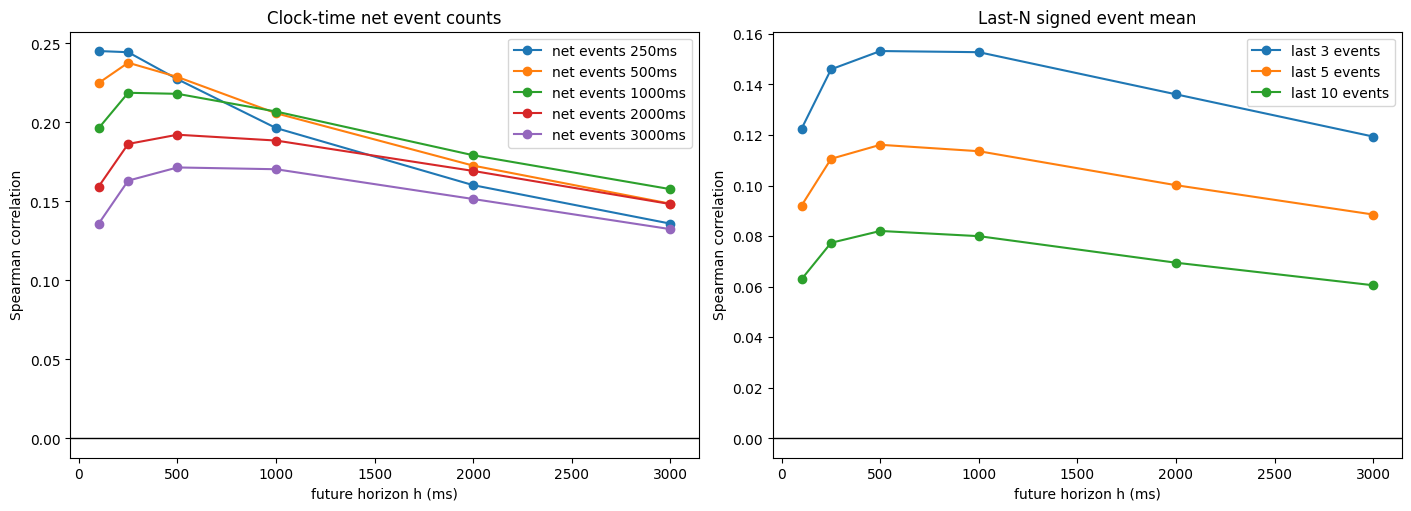

In [9]:
def _safe_corr(left: pd.Series, right: pd.Series, *, method: str) -> float:
    valid = left.notna() & right.notna()
    if valid.sum() < 3:
        return np.nan
    if left.loc[valid].nunique() < 2 or right.loc[valid].nunique() < 2:
        return np.nan
    return float(left.loc[valid].corr(right.loc[valid], method=method))


def build_event_signal_correlations(
    frame: pd.DataFrame,
    *,
    windows_ms: list[int],
    counts_n: list[int],
    horizons_ms: list[int],
) -> pd.DataFrame:
    rows = []
    signals = ["rho"]
    for window_ms in windows_ms:
        signals.extend(
            [
                f"buy_event_count_{window_ms}ms",
                f"sell_event_count_{window_ms}ms",
                f"net_event_count_{window_ms}ms",
                f"total_event_count_{window_ms}ms",
            ]
        )
    for n_events in counts_n:
        signals.extend(
            [
                f"last_{n_events}_buy_count",
                f"last_{n_events}_sell_count",
                f"last_{n_events}_event_count",
                f"last_{n_events}_buy_share",
                f"last_{n_events}_signed_event_mean",
            ]
        )

    for horizon_ms in horizons_ms:
        target = f"delta_mid_{horizon_ms}ms"
        for signal in signals:
            rows.append(
                {
                    "horizon_ms": horizon_ms,
                    "signal": signal,
                    "pearson": _safe_corr(frame[signal], frame[target], method="pearson"),
                    "spearman": _safe_corr(frame[signal], frame[target], method="spearman"),
                    "n": int((frame[signal].notna() & frame[target].notna()).sum()),
                }
            )
    return pd.DataFrame(rows)


correlation_table = build_event_signal_correlations(
    features,
    windows_ms=EVENT_WINDOWS_MS,
    counts_n=LAST_EVENT_COUNTS_N,
    horizons_ms=FUTURE_PRICE_HORIZONS_MS,
)
display(correlation_table.sort_values(["horizon_ms", "spearman"], ascending=[True, False]).head(DISPLAY_ROWS))

net_corr = correlation_table[correlation_table["signal"].str.startswith("net_event_count_")].copy()
net_corr["window_ms"] = net_corr["signal"].str.extract(r"net_event_count_(\d+)ms").astype(int)

last_n_corr = correlation_table[correlation_table["signal"].str.endswith("_signed_event_mean")].copy()
last_n_corr["n_events"] = last_n_corr["signal"].str.extract(r"last_(\d+)_signed_event_mean").astype(int)

display(last_n_corr.sort_values(["horizon_ms", "spearman"], ascending=[True, False]).head(DISPLAY_ROWS))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for window_ms, part in net_corr.groupby("window_ms"):
    part = part.sort_values("horizon_ms")
    axes[0].plot(part["horizon_ms"], part["spearman"], marker="o", label=f"net events {window_ms}ms")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Clock-time net event counts")
axes[0].set_xlabel("future horizon h (ms)")
axes[0].set_ylabel("Spearman correlation")
axes[0].legend()

for n_events, part in last_n_corr.groupby("n_events"):
    part = part.sort_values("horizon_ms")
    axes[1].plot(part["horizon_ms"], part["spearman"], marker="o", label=f"last {n_events} events")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Last-N signed event mean")
axes[1].set_xlabel("future horizon h (ms)")
axes[1].set_ylabel("Spearman correlation")
axes[1].legend()
plt.show()


## 10. Interpretation Notes

Use this section after running the notebook.

Things to check:

- Are event-count signals more correlated with future price changes than snapshot `rho_t`?
- Does `net_event_count_W` have the expected sign across horizons?
- Does a short window such as `500ms` work better than a longer window such as `3000ms`?
- Do `buy_count_positive` and `sell_count_positive` have opposite signs in `mean_delta_mid`?
- Does `repeated_events` behave differently from `one_or_more_events`?
- Is the effect driven by enough observations, or only by rare repeated-event periods?
- If event counts look useful, compare them later with time-in-state features: event count measures repeated entries, while time-in-state measures persistence.
- Does `last_N_signed_event_mean` add information beyond the clock-time `net_event_count_W` feature?
- Does a short event window such as `last_3` work better than a longer event window such as `last_10`?
